In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el archivo 
df = pd.read_csv('/Users/sebastiangutierrezf/Desktop/customer-churn-strategy/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.info()) 
print(df.head())

# 1. Limpieza técnica: TotalCharges tiene espacios vacíos que detectamos como NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 2. Variable objetivo: Convertimos Churn a números (1=Sí, 0=No) para calcular promedios
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print(f"Análisis listo para {df.shape[0]} clientes.")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2]:
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

Tasa de fuga por contrato:
Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn_Numeric, dtype: float64


/var/folders/d9/rl9prf054mx41hczt_khk1q40000gn/T/ipykernel_36892/1422664353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contratos_analisis.index, y=contratos_analisis.values, palette='Blues_d')


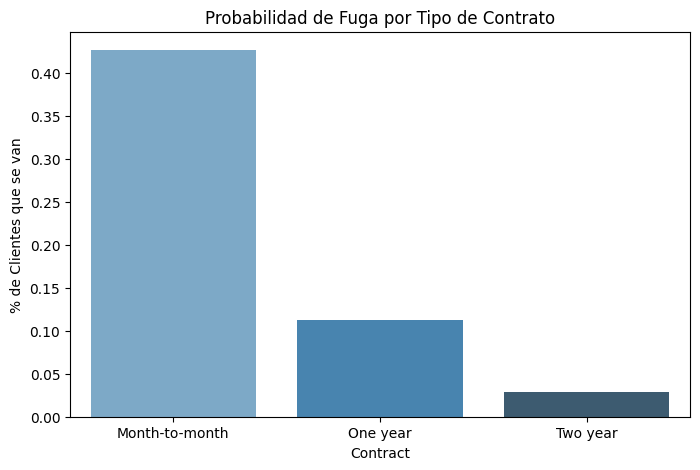

In [3]:
# Sacamos el promedio de fuga por tipo de contrato
contratos_analisis = df.groupby('Contract')['Churn_Numeric'].mean()
print("Tasa de fuga por contrato:")
print(contratos_analisis)

# Graficamos para la presentación final
plt.figure(figsize=(8,5))
sns.barplot(x=contratos_analisis.index, y=contratos_analisis.values, palette='Blues_d')
plt.title('Probabilidad de Fuga por Tipo de Contrato')
plt.ylabel('% de Clientes que se van')
plt.show()

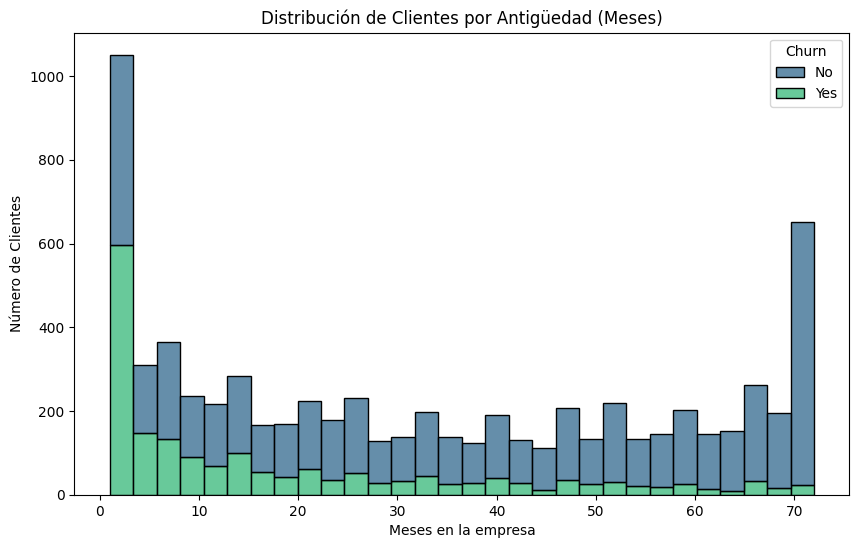

In [4]:


# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Creamos un histograma
# x='tenure': los meses que lleva el cliente
# hue='Churn': divide las barras entre los que se fueron (1) y los que no (0)
# multiple='stack': apila las barras para ver el total
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='viridis', bins=30)

plt.title('Distribución de Clientes por Antigüedad (Meses)')
plt.xlabel('Meses en la empresa')
plt.ylabel('Número de Clientes')
plt.show()

Mirando el histograma, podemos concluir:

El "Pico del Abandono" (Meses 0-5): En la primera barra verde (Churn=Yes). Es altísima, llega casi a los 600 clientes. Esto nos dice que la mayoría de las fugas ocurren en los primeros meses.

Estrategia: La empresa debe mejorar la "Bienvenida" o el "Onboarding". Si el cliente sobrevive al primer año, es mucho más probable que se quede.

La "Zona de Lealtad" (Meses 70+): Mira la última barra a la derecha. Es casi toda azul (Churn=No). Los clientes que llevan más de 6 años son extremadamente fieles.

Para que mi análisis avance, tengo que resolver un problema técnico fundamental: las computadoras y los modelos de Inteligencia Artificial que voy a usar son, en esencia, calculadoras gigantes.

El Conflicto: Mi base de datos actual tiene muchas palabras como "Fiber optic", "Female" o "Month-to-month".

La Realidad: Los modelos de IA no saben qué hacer con el texto; ellos solo procesan y entienden números.

La Solución: One-Hot Encoding

Para solucionar esto, en la siguiente celda voy a aplicar una técnica llamada One-Hot Encoding. Básicamente, voy a convertir las palabras en columnas de 1 y 0.

Por ejemplo: La columna gender se dividirá en dos nuevas columnas: gender_Male y gender_Female. Si el cliente es hombre, tendrá un 1 en la columna de hombre y un 0 en la de mujer.

In [5]:
# 1. Eliminamos el customerID porque es un código que no ayuda a predecir
df.drop('customerID', axis=1, inplace=True)

# 2. Convertimos todas las palabras en columnas de 1 y 0
# Esto se llama One-Hot Encoding
df_final = pd.get_dummies(df, drop_first=True)

# 3. Vemos cómo ha quedado nuestra nueva tabla
print("Nuevas columnas creadas:")
print(df_final.columns)
print(df_final.head())

Nuevas columnas creadas:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Churn_Numeric', 'gender_Male', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn_Nume

Para garantizar la capacidad de generalización del modelo y evitar el sobreajuste (overfitting), procederemos a separar la variable objetivo del conjunto de predictores. Posteriormente, realizaremos una división aleatoria del dataset en un 80% para entrenamiento y un 20% para validación externa.

In [7]:
from sklearn.model_selection import train_test_split

# 1. Separamos los datos: X son las preguntas, y es la respuesta
X = df_final.drop(['Churn_Numeric', 'Churn_Yes'], axis=1) # Todas las columnas menos Churn
y = df_final['Churn_Numeric'] # Solo la columna Churn

# 2. Dividimos: test_size=0.2 significa 20% para examen
# random_state=42 es para que, si repites el código, la división sea siempre la misma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos totales: {len(df_final)}")
print(f"Entrenaremos con: {len(X_train)} clientes")
print(f"Probaremos con: {len(X_test)} clientes")

Datos totales: 7032
Entrenaremos con: 5625 clientes
Probaremos con: 1407 clientes


In [8]:
from sklearn.ensemble import RandomForestClassifier

# 1. Creamos el modelo 
# n_estimators=100 significa que usaremos 100 árboles (expertos)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. ENTRENAMIENTO: Aquí la IA estudia los datos
# Le pasamos las preguntas (X_train) y las respuestas (y_train)
modelo.fit(X_train, y_train)

# 3. PREDICCIÓN
predicciones = modelo.predict(X_test)

print("¡Modelo entrenado y examen completado!")

¡Modelo entrenado y examen completado!


In [9]:
predicciones[:10]  

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0])

Nota final del examen (Accuracy): 78.54%


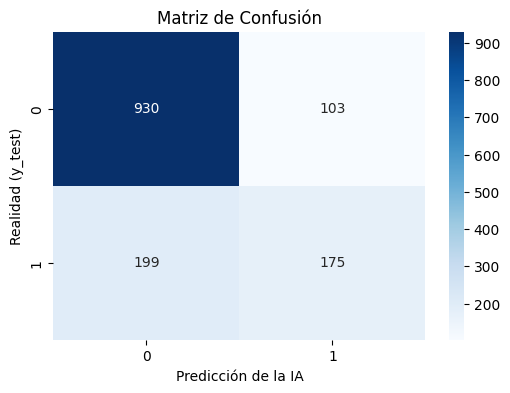

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Calculamos la precisión global
exactitud = accuracy_score(y_test, predicciones)
print(f"Nota final del examen (Accuracy): {exactitud:.2%}")

# 2. Creamos la Matriz de Confusión para ver los detalles
matriz = confusion_matrix(y_test, predicciones)

# 3. Graficamos la matriz para que se entienda mejor
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad (y_test)')
plt.show()

/var/folders/d9/rl9prf054mx41hczt_khk1q40000gn/T/ipykernel_36892/3274329291.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')


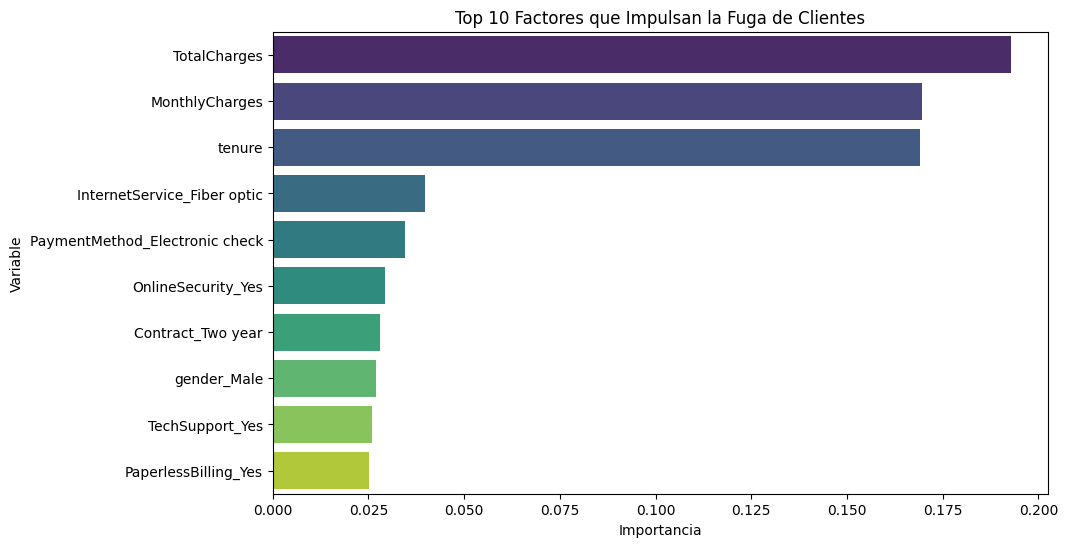

In [11]:
# Extraemos la importancia de las variables del modelo
importancias = pd.DataFrame({'Variable': X.columns, 'Importancia': modelo.feature_importances_})
importancias = importancias.sort_values(by='Importancia', ascending=False).head(10)

# Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')
plt.title('Top 10 Factores que Impulsan la Fuga de Clientes')
plt.show()

# Conclusión General del Proyecto
## Resultados Técnicos

Exactitud Final: 78.54% tras eliminar el sesgo de datos (target leakage), lo que garantiza un modelo fiable para entornos de producción reales.

Matriz de Confusión: El modelo demuestra una capacidad robusta para distinguir entre clientes leales y en riesgo, permitiendo una intervención quirúrgica sobre la cartera.

# Hallazgos de Negocio (Insights)

Sensibilidad al Gasto: Las variables de facturación (TotalCharges y MonthlyCharges) son los indicadores de fuga más potentes. Un aumento repentino o un cargo total elevado sin antigüedad proporcional disparan las alarmas.

La Barrera de la Antigüedad: El riesgo de fuga es crítico durante los primeros 5 meses. Superar el primer año de vida del cliente aumenta drásticamente su Lifetime Value.

Inestabilidad Contractual: El contrato "mes a mes" es el mayor enemigo de la retención, con una tasa de fuga del 42.7%.

# Recomendación Ejecutiva

Implementar un sistema de Alerta Temprana que identifique a los clientes en su primer semestre con contratos mensuales y cargos elevados. Proponer a este segmento una migración a planes anuales con beneficios exclusivos para "congelar" el flujo de caja y reducir la tasa de atrición global.